In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

In [37]:
# ── Constants ─────────────────────────────────────────────────────────────────
DATA_ROOT_PATH    = "/home/frankie/WCIS/FLASH-ADC-CHARACTERIZATION/ramp_data_final/TOP"
# DATA_ROOT_PATH    = "/home/frankie/WCIS/FLASH-ADC-CHARACTERIZATION/data_FINAL/BOTTOM"
POWER_MODES       = ["HPM", "RPM", "LPM"]
FS_STR_LIST       = ["500k", "1M", "2M", "3M", "4M", "5M", "6M"]
FS_LIST           = [500e3, 1e6, 2e6, 3e6, 4e6, 5e6, 6e6]
FI_LIST           = [99.915e3, 99.976e3, 99.854e3, 99.976e3, 100.098e3, 99.487e3, 98.877e3]
J_LIST            = [1637, 819, 409, 273, 205, 163, 135]
BUFFER_SIZE       = 8192
REF_HI            = 2.8
REF_LO            = 0.8
SHUNT_RESISTANCE  = 1.02

SHUNT_VOLTAGE = {
    "HPM": {"500k": 4.62e-3, "1M": 4.98e-3, "2M": 5.62e-3, "3M": 6.16e-3, "4M": 6.74e-3, "5M": 7.32e-3, "6M": 0},
    "RPM": {"500k": 3.25e-3, "1M": 3.60e-3, "2M": 4.20e-3, "3M": 4.80e-3, "4M": 5.38e-3, "5M": 5.93e-3, "6M": 0},
    "LPM": {"500k": 2.50e-3, "1M": 2.89e-3, "2M": 3.52e-3, "3M": 3.96e-3, "4M": 4.39e-3, "5M": 4.98e-3, "6M": 0},
}

POWER_W = {
    pm: {fs: (v**2 / SHUNT_RESISTANCE) for fs, v in fs_dict.items()}
    for pm, fs_dict in SHUNT_VOLTAGE.items()
}

hann_window = np.hanning(BUFFER_SIZE)

In [38]:
# ── Load raw data ─────────────────────────────────────────────────────────────
raw_dfs = {pm: pd.DataFrame() for pm in POWER_MODES}

for power_mode_folder in os.listdir(DATA_ROOT_PATH):
    power_mode_folder_path = os.path.join(DATA_ROOT_PATH, power_mode_folder)
    if os.path.isdir(power_mode_folder_path) and power_mode_folder in POWER_MODES:
        for Fs_folder in os.listdir(power_mode_folder_path):
            Fs_path = os.path.join(power_mode_folder_path, Fs_folder)
            if os.path.isdir(Fs_path):
                for csv_file in glob.glob(os.path.join(Fs_path, "*.csv")):
                    df = pd.read_csv(csv_file)
                    for k, col in enumerate(df.columns):
                        raw_dfs[power_mode_folder][Fs_folder + str(k)] = df[col]


/tmp/ipykernel_292858/2979450427.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw_dfs[power_mode_folder][Fs_folder + str(k)] = df[col]


Total samples : 819200
Unique codes  : 196
Code range    : 0 – 255


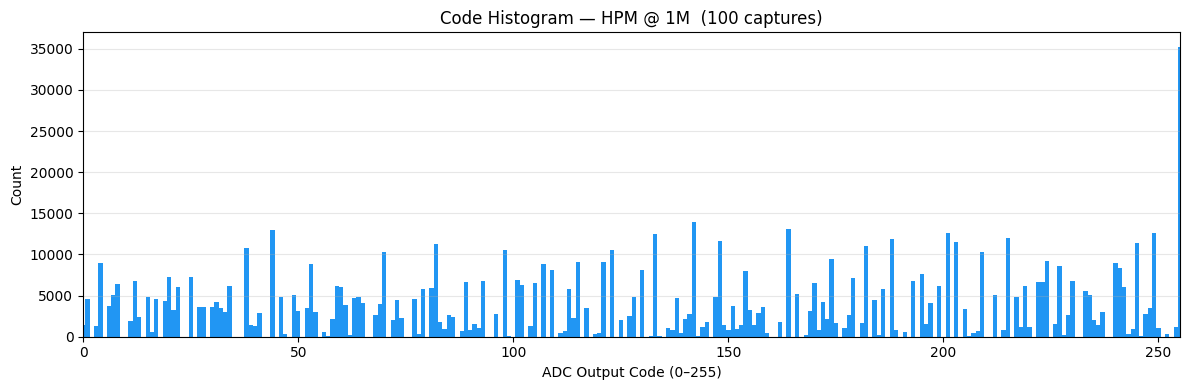

In [39]:
# ── Pick power mode and Fs to plot ───────────────────────────────────────────
pm_plot     = "HPM"
fs_plot     = "1M"

# ── Gather all codes across all captures for this pm/fs ──────────────────────
test_cols = [c for c in raw_dfs[pm_plot].columns if c.startswith(fs_plot)]
all_codes = np.concatenate([raw_dfs[pm_plot][col].dropna().values.astype(int)
                             for col in test_cols])

print(f"Total samples : {len(all_codes)}")
print(f"Unique codes  : {len(np.unique(all_codes))}")
print(f"Code range    : {all_codes.min()} – {all_codes.max()}")

# ── Histogram ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(np.arange(256),
       np.bincount(all_codes, minlength=256),
       width=1.0, color="#2196F3", edgecolor="none")

ax.set_title(f"Code Histogram — {pm_plot} @ {fs_plot}  ({len(test_cols)} captures)")
ax.set_xlabel("ADC Output Code (0–255)")
ax.set_ylabel("Count")
ax.set_xlim(0, 255)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

Hm = 3080.78 counts (ideal bin height)
DNL max = +3.520 LSB,  min = -1.000 LSB
INL max = +4.175 LSB,  min = -8.640 LSB


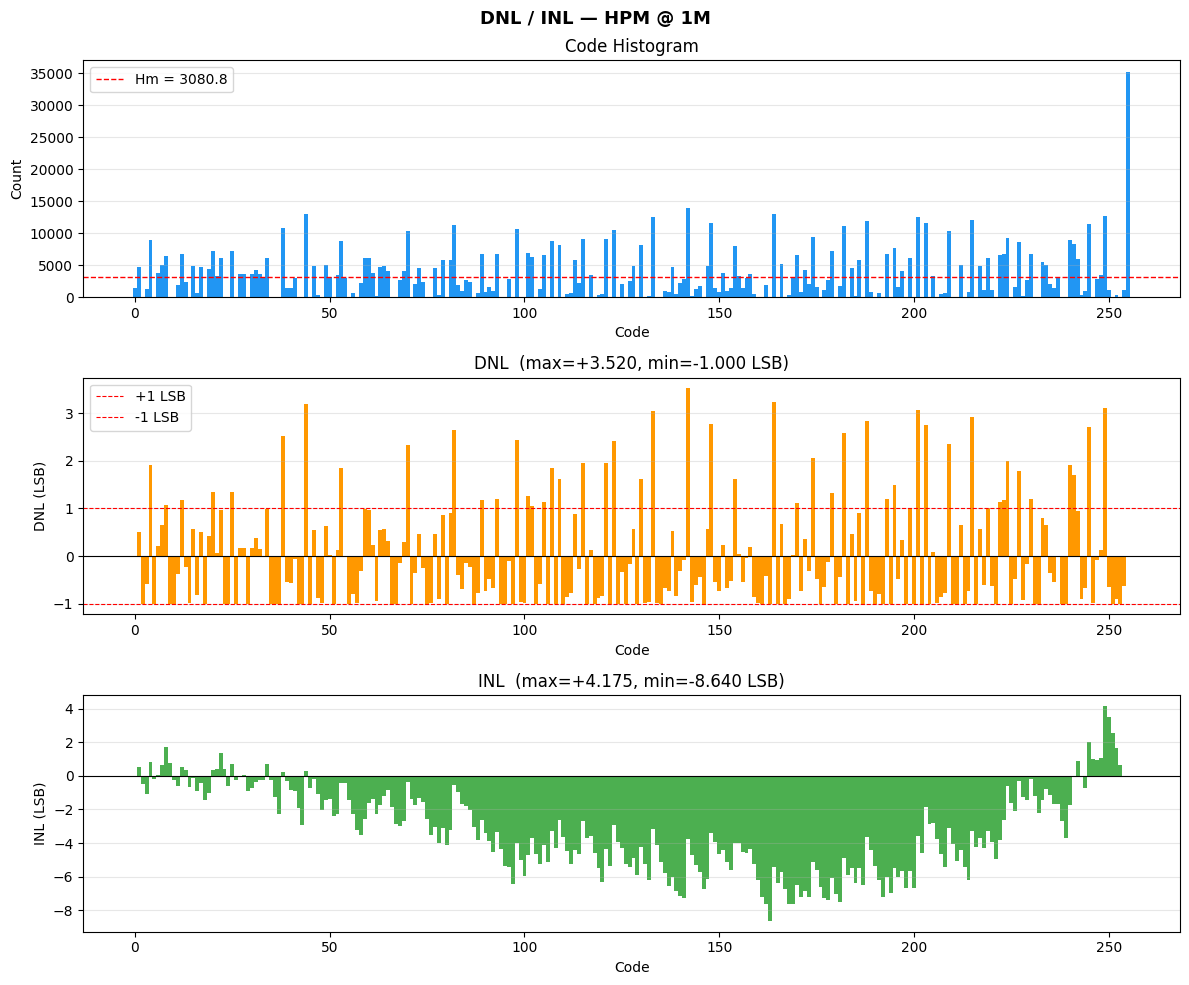

In [40]:
# ── Histogram H[i] ────────────────────────────────────────────────────────────
H = np.bincount(all_codes, minlength=256)   # H[0..255]

# ── Hm: average bin height from code 1 to 2^n - 2 (eq. 15) ──────────────────
n   = 8
Hm  = np.sum(H[1:2**n - 1]) / (2**n - 2)
print(f"Hm = {Hm:.2f} counts (ideal bin height)")

# ── DNL: eq. 16 ───────────────────────────────────────────────────────────────
DNL = np.zeros(256)
for i in range(1, 2**n - 1):
    DNL[i] = (H[i] / Hm) - 1.0
# endpoints defined as 0 per the paper
DNL[0]       = 0.0
DNL[2**n -1] = 0.0

# ── INL: eq. 17 — cumulative sum of DNL ──────────────────────────────────────
INL = np.zeros(256)
for i in range(1, 2**n - 1):
    INL[i] = np.sum(DNL[1:i+1])
INL[0]       = 0.0
INL[2**n -1] = 0.0

print(f"DNL max = +{DNL.max():.3f} LSB,  min = {DNL.min():.3f} LSB")
print(f"INL max = +{INL.max():.3f} LSB,  min = {INL.min():.3f} LSB")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle(f"DNL / INL — {pm_plot} @ {fs_plot}", fontsize=13, fontweight="bold")

# Histogram
axes[0].bar(np.arange(256), H, width=1.0, color="#2196F3", edgecolor="none")
axes[0].axhline(Hm, color="red", linestyle="--", linewidth=1, label=f"Hm = {Hm:.1f}")
axes[0].set_title("Code Histogram")
axes[0].set_xlabel("Code"); axes[0].set_ylabel("Count")
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis="y")

# DNL
axes[1].bar(np.arange(256), DNL, width=1.0, color="#FF9800", edgecolor="none")
axes[1].axhline( 0, color="black", linewidth=0.8)
axes[1].axhline( 1, color="red",   linewidth=0.8, linestyle="--", label="+1 LSB")
axes[1].axhline(-1, color="red",   linewidth=0.8, linestyle="--", label="-1 LSB")
axes[1].set_title(f"DNL  (max=+{DNL.max():.3f}, min={DNL.min():.3f} LSB)")
axes[1].set_xlabel("Code"); axes[1].set_ylabel("DNL (LSB)")
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis="y")

# INL
axes[2].bar(np.arange(256), INL, width=1.0, color="#4CAF50", edgecolor="none")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title(f"INL  (max=+{INL.max():.3f}, min={INL.min():.3f} LSB)")
axes[2].set_xlabel("Code"); axes[2].set_ylabel("INL (LSB)")
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [41]:
offset_error = INL[1]   # INL deviation at first code

# Fit a line to INL[1..254]
codes = np.arange(1, 255)
slope, intercept = np.polyfit(codes, INL[1:255], 1)
gain_error   = slope      # LSB/code
offset_error = intercept  # LSB

INL_corrected = np.zeros(256)
for i in range(1, 255):
    INL_corrected[i] = INL[i] - (slope * i + intercept)

# Recompute DNL from corrected INL
DNL_corrected = np.zeros(256)
DNL_corrected[1] = INL_corrected[1]
for i in range(2, 255):
    DNL_corrected[i] = INL_corrected[i] - INL_corrected[i-1]

print(f"Gain error   = {slope:.4f} LSB/code")
print(f"Offset error = {intercept:.4f} LSB")
print(f"Corrected INL max = +{INL_corrected.max():.3f}, min = {INL_corrected.min():.3f} LSB")
print(f"Corrected DNL max = +{DNL_corrected.max():.3f}, min = {DNL_corrected.min():.3f} LSB")

Gain error   = -0.0109 LSB/code
Offset error = -1.7463 LSB
Corrected INL max = +8.645, min = -5.111 LSB
Corrected DNL max = +3.531, min = -0.989 LSB
